In [1]:
import numpy as np
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, show, savefig, close
import matplotlib.font_manager as fm
import itertools
from matplotlib import rcParams
import scienceplots
import pickle

from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches
from matplotlib.patches import Patch

In [2]:
planet_names = ["HD3167","K2141","LHS1478","TOI431","TOI500","TOI561","TOI1416","TOI1807"]
planet_fullnames = ["HD3167b","K2-141b","LHS1478b","TOI-431b","TOI-500b","TOI-561b","TOI-1416b","TOI-1807b"]
planet_masses = [4.73, 4.97, 2.33, 3.07, 1.42, 2.02, 3.48, 2.44] #Earth masses
planet_distances = [0.018, 0.007, 0.018, 0.011, 0.012, 0.011, 0.019, 0.012] #AU
planet_period = [0.96, 0.28, 1.95, 0.49, 0.55, 0.45, 1.0, 0.55] #days
planet_radius = [1.627, 1.510, 1.242, 1.277, 1.166, 1.397, 1.620, 1.496] #Earth radii
planet_transit = [1.61, 0.94, 0.71, 1.24, 0.99, 1.31, 1.5, 0.98] #hours
planet_transit = [n * 3600 for n in planet_transit] #hours to seconds
T_transit_hours = [1.61, 0.94, 0.71, 1.24, 0.99, 1.31, 1.5, 0.98] #hours
planet_impact = [0.181, -0.01, 0.717, 0.34, 0.53, 0.14, 0.39, 0.489] #to be fixed according to archive data
planet_eccentricity = [0.05, 0.0, 0.0, 0.0, 0.06, 0.0, 0.0, 0.0] #to be fixed according to archive data
planet_pericentre_long = [0.0, 90.0, 0.0, 0.0, 228.5, 0.0, 0.0, 90.0] #w, to be fixed according to archive data

star_temperature = [5261.0,4570.0,3381.0,4850.0,4440.0,5342.0,4884.0,4914.0] #Kelvin
star_radius = [0.872,0.681,0.246,0.731,0.678,0.856,0.793,0.746] #Solar radii
star_metallicity = [0.03, 0.0, -0.13, 0.2, 0.12, -0.4, 0.08, -0.04] #[Fe/H]
star_logg = [4.5, 4.6, 4.9, 4.6, 4.6, 4.5, 4.5, 4.6]
star_age = [10.2, 6.3, 5.6, 5.1, 5, 11, 6.9, 0.3] #Gyr
star_distance = [47.28, 61.87, 18.22, 32.6, 47.39, 85.8, 55.01, 42.58] #pc, to be fixed

In [3]:
planet_names = ["HD3167","K2141","lhs1478","TOI431","TOI500","TOI561","TOI1416","TOI1807"]

m_min = [4.44, 4.63, 2.31, 2.72, 1.24,  1.79, 3.01, 1.87]
m_max = [5.01, 5.32, 2.35, 3.42, 1.60,  2.25, 3.95, 3.04]

r_min = [1.569, 1.46, 1.193, 1.24, 1.04, 1.37, 1.54, 1.43]
r_max = [1.71, 1.56, 1.293, 1.32, 1.28, 1.424, 1.70, 1.587]

star_age = [10.2, 6.3, 5.6, 5.1, 5, 11, 6.9, 0.3]
star_age = np.array(star_age)*1e9

star_age_min = np.array([7.8,1.6,1.9,4.5,4.8,7.5,6.8,0.22])*1e9
star_age_max = np.array([13,12.5,8.3,5.7,5.2,13.8,7.0,0.38])*1e9

def average(arr_max, arr_min):
    arr = np.zeros(len(arr_max))
    for i in range(len(arr_max)):
        arr[i] = (arr_max[i] + arr_min[i]) / 2
    return arr

def bulk_density(m,r):
    return (3/4) * (1/np.pi) * (m / r**3)

m_avg = average(m_max, m_min)
r_avg = average(r_max, r_min)

bulk_density_avg = bulk_density(m_avg, r_avg)
bulk_density_max = bulk_density(np.array(m_max), np.array(r_min))
bulk_density_min = bulk_density(np.array(m_min), np.array(r_max))

#convert to g/cm^3
bulk_density_avg = bulk_density_avg * 23.04
bulk_density_max = bulk_density_max * 23.04
bulk_density_min = bulk_density_min * 23.04

In [42]:
rcParams['xtick.direction'] = 'in'         # ticks pointing inward (standard in astronomy)
rcParams['ytick.direction'] = 'in'
rcParams['xtick.top'] = True               # mirror ticks on top
rcParams['ytick.right'] = True
rcParams['xtick.major.size'] = 5
rcParams['xtick.minor.size'] = 3
rcParams['xtick.minor.visible'] = True
rcParams['ytick.minor.visible'] = True

rcParams['axes.linewidth'] = 2
rcParams['axes.grid'] = True
rcParams['grid.alpha'] = 0.8
rcParams['grid.linestyle'] = '-'

rcParams['font.family'] = 'serif'          # or 'sans-serif' (Nature/AAS style)
rcParams['font.serif'] = ['Times New Roman']
rcParams['font.size'] = 16
rcParams['axes.labelsize'] = 22            # axis label size
rcParams['xtick.labelsize'] = 20
rcParams['ytick.labelsize'] = 20
rcParams['legend.fontsize'] = 16
rcParams['text.usetex'] = True             # render labels with LaTeX

## Scatter Plots

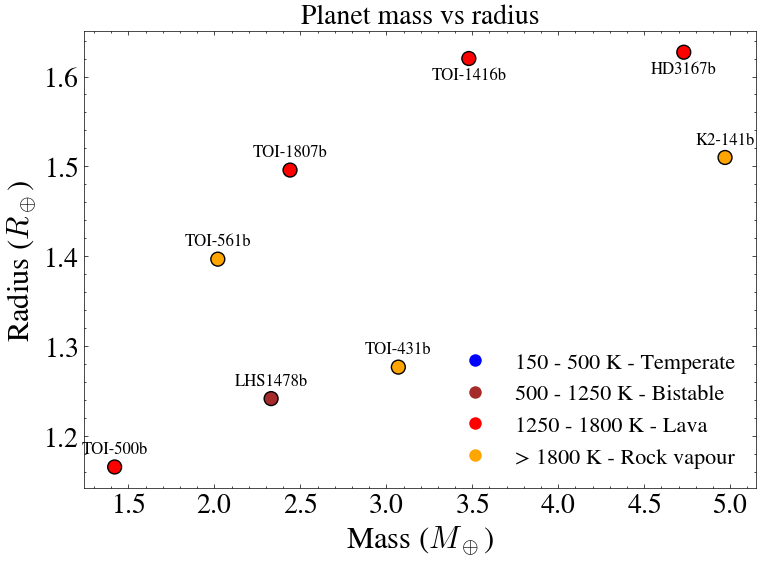

In [43]:
plt.style.use(['science', 'no-latex'])

#set color based on equilibrium temperature
planet_equilibrium_temperature = [1500, 2000, 750, 2000, 1500, 2000, 1500, 1500] #K, to be fixed according to archive data

if len(planet_equilibrium_temperature) == len(planet_names):
    colors = []
    for T in planet_equilibrium_temperature:
        if T < 500:
            colors.append('blue')
        elif 500 <= T < 1250:
            colors.append('brown')
        elif 1250 <= T < 1800:
            colors.append('red')
        else:
            colors.append('orange')

# scatter plot of planet mass vs radius
fig = figure(figsize=(8, 6))
frame = fig.add_subplot(1, 1, 1)

frame.scatter(planet_masses, planet_radius, color=colors, s=100, edgecolor='black')

for i, name in enumerate(planet_names):
    if name != "TOI1416" and name != "HD3167":
        frame.annotate(planet_fullnames[i], (planet_masses[i], planet_radius[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=12)
    else:
        #annotate them but below the point instead of above it
        frame.annotate(planet_fullnames[i], (planet_masses[i], planet_radius[i]), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=12)
#create label for colors
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='150 - 500 K - Temperate', markerfacecolor='blue', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='500 - 1250 K - Bistable', markerfacecolor='brown', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='1250 - 1800 K - Lava', markerfacecolor='red', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='> 1800 K - Rock vapour', markerfacecolor='orange', markersize=10)]


frame.set_title('Planet mass vs radius',fontsize=20)
frame.set_xlabel(r'Mass ($M_\oplus$)')
frame.set_ylabel(r'Radius ($R_\oplus$)')

frame.tick_params(axis='both', which='major')

frame.grid()
frame.legend(handles=legend_elements, loc='lower right')
#tight layout
plt.tight_layout()
savefig('thesis-plots/planet_mass_radius_scatter.pdf', bbox_inches='tight')
show()

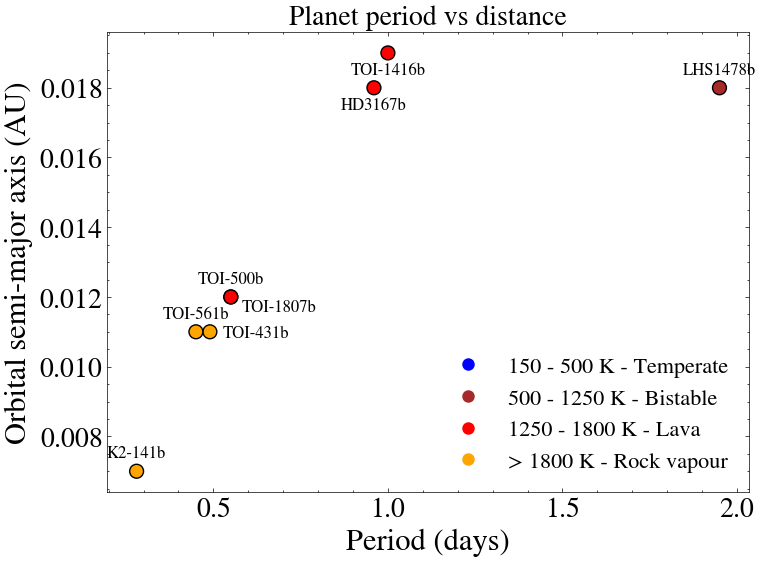

In [44]:
# scatter plot of planet mass vs radius

fig = figure(figsize=(8, 6))
frame = fig.add_subplot(1, 1, 1)

frame.scatter(planet_period, planet_distances, color=colors, s=100, edgecolor='black')

for i, name in enumerate(planet_names):
    if name != "TOI1416" and name != "HD3167" and name != "LHS1478" and name != "TOI431" and name != "TOI1807":
        frame.annotate(planet_fullnames[i], (planet_period[i], planet_distances[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=12)
    elif name == "LHS1478":
        frame.annotate(planet_fullnames[i], (planet_period[i], planet_distances[i]), textcoords="offset points", xytext=(-7,10), ha='center', fontsize=12)
    elif name == "TOI431":
        frame.annotate(planet_fullnames[i], (planet_period[i], planet_distances[i]), textcoords="offset points", xytext=(33,-4), ha='center', fontsize=12)
    elif name == "TOI1807":
        frame.annotate(planet_fullnames[i], (planet_period[i], planet_distances[i]), textcoords="offset points", xytext=(35,-10), ha='center', fontsize=12)
    else:
        #annotate them but below the point instead of above it
        frame.annotate(planet_fullnames[i], (planet_period[i], planet_distances[i]), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=12)

#create label for colors
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='150 - 500 K - Temperate', markerfacecolor='blue', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='500 - 1250 K - Bistable', markerfacecolor='brown', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='1250 - 1800 K - Lava', markerfacecolor='red', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='> 1800 K - Rock vapour', markerfacecolor='orange', markersize=10)]


frame.set_title('Planet period vs distance',fontsize=20)
frame.set_xlabel(r'Period (days)')
frame.set_ylabel(r'Orbital semi-major axis (AU)')

frame.tick_params(axis='both', which='major')

frame.grid()
frame.legend(handles=legend_elements, loc='lower right')
#tight layout
plt.tight_layout()
savefig('thesis-plots/planet_period_distance_scatter.pdf', bbox_inches='tight')
show()

# Validation plots

In [46]:
#for all planets except toi-431, lhs1478 and k2141

with open('bulk_density_evolution.pkl', 'rb') as f:
    data_all = pickle.load(f)

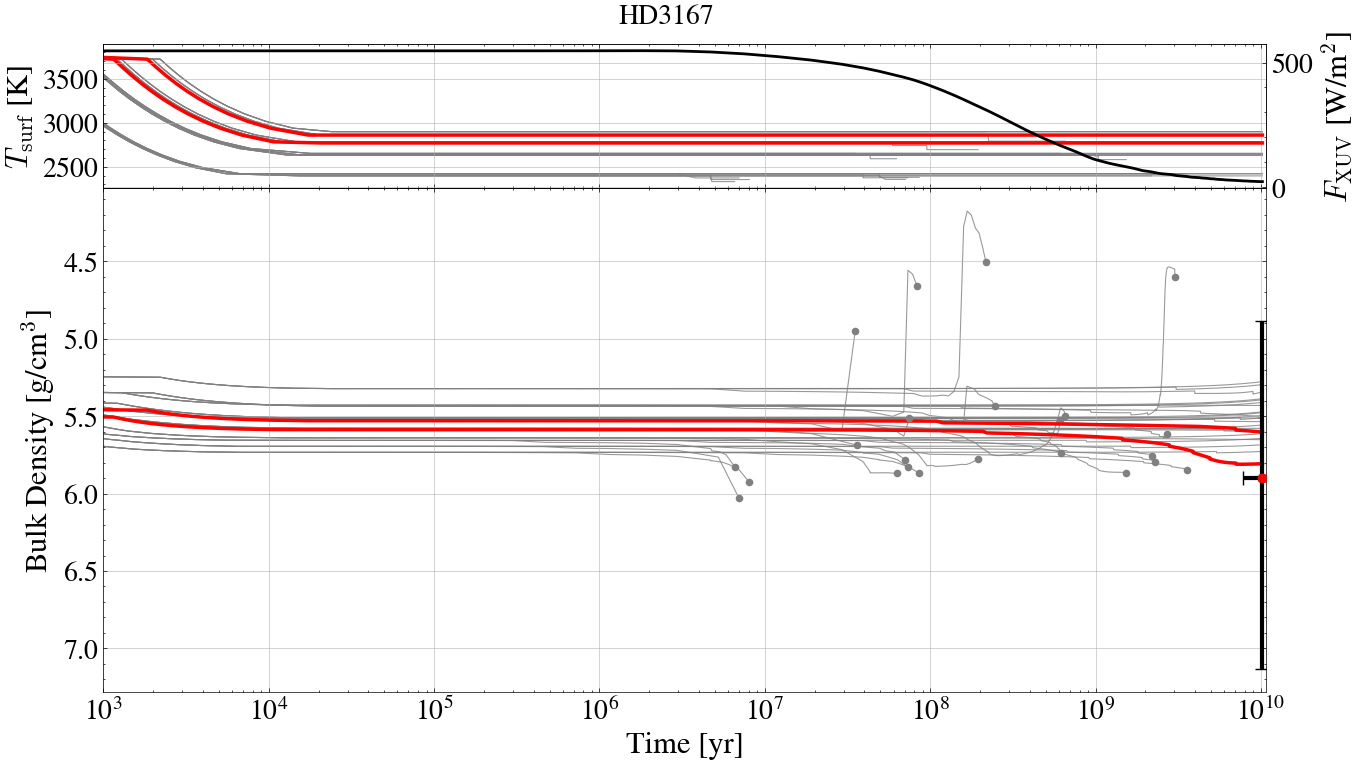

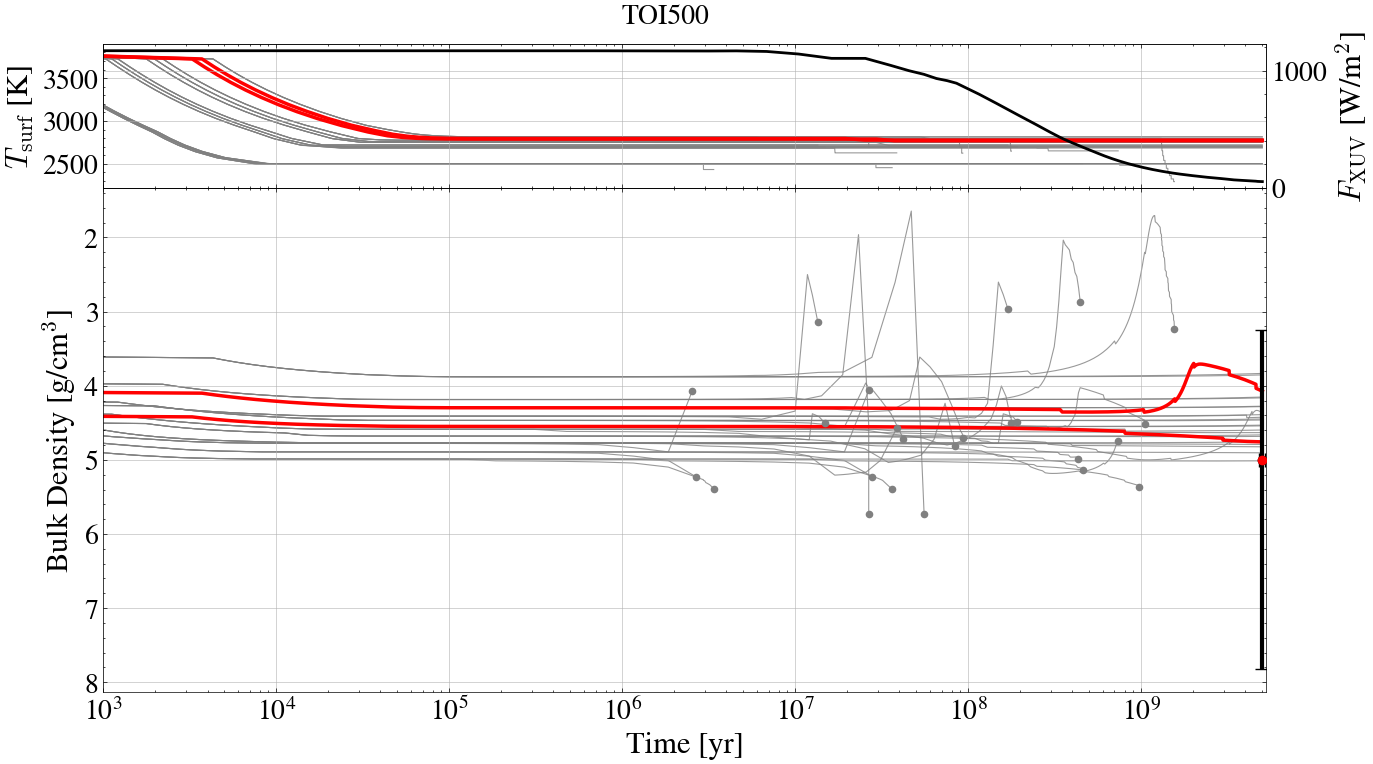

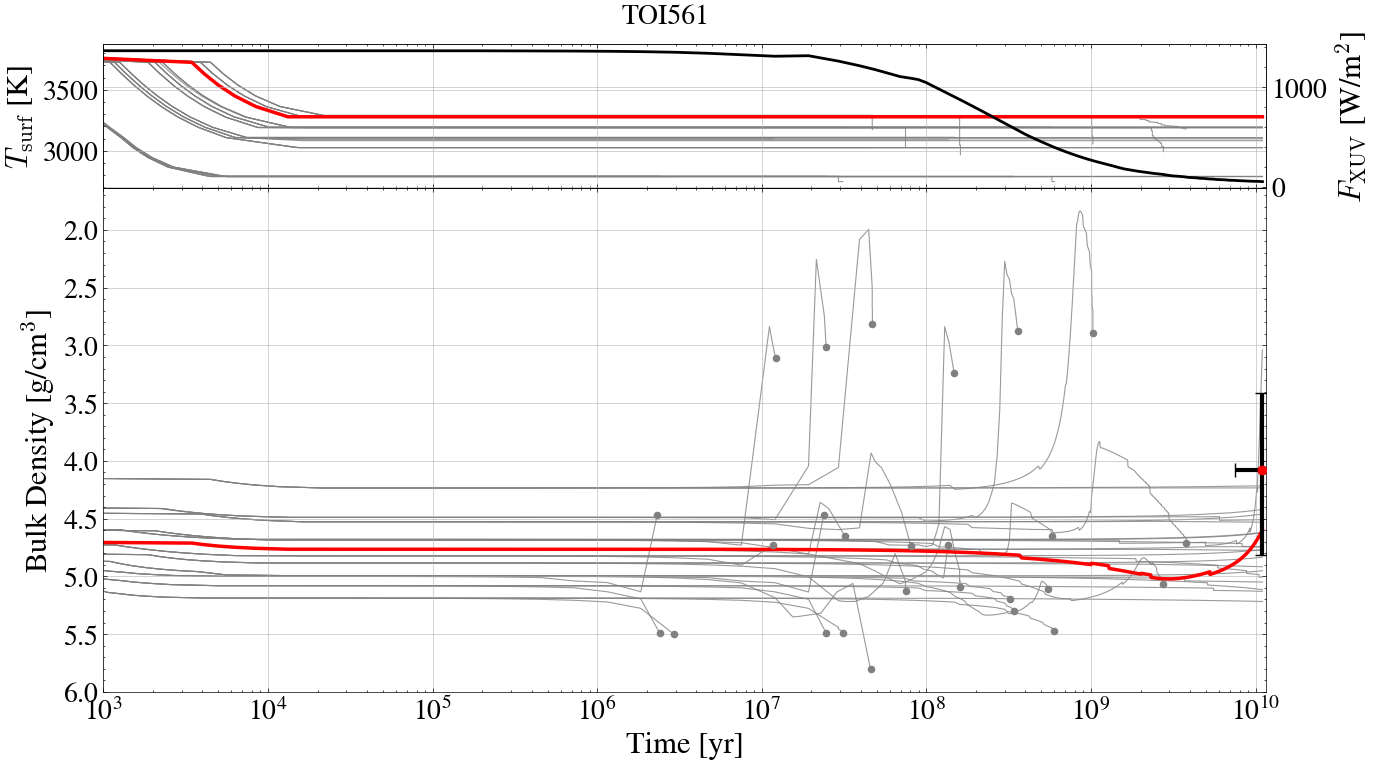

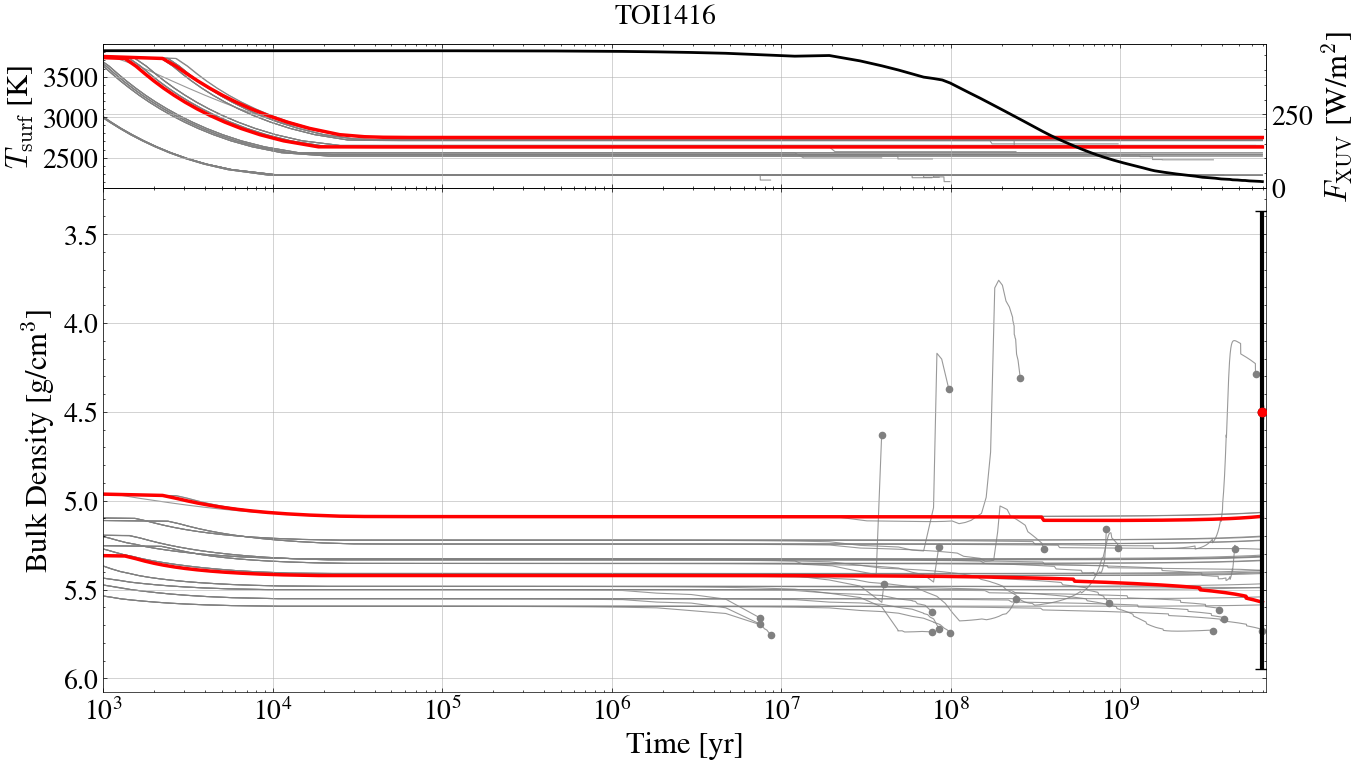

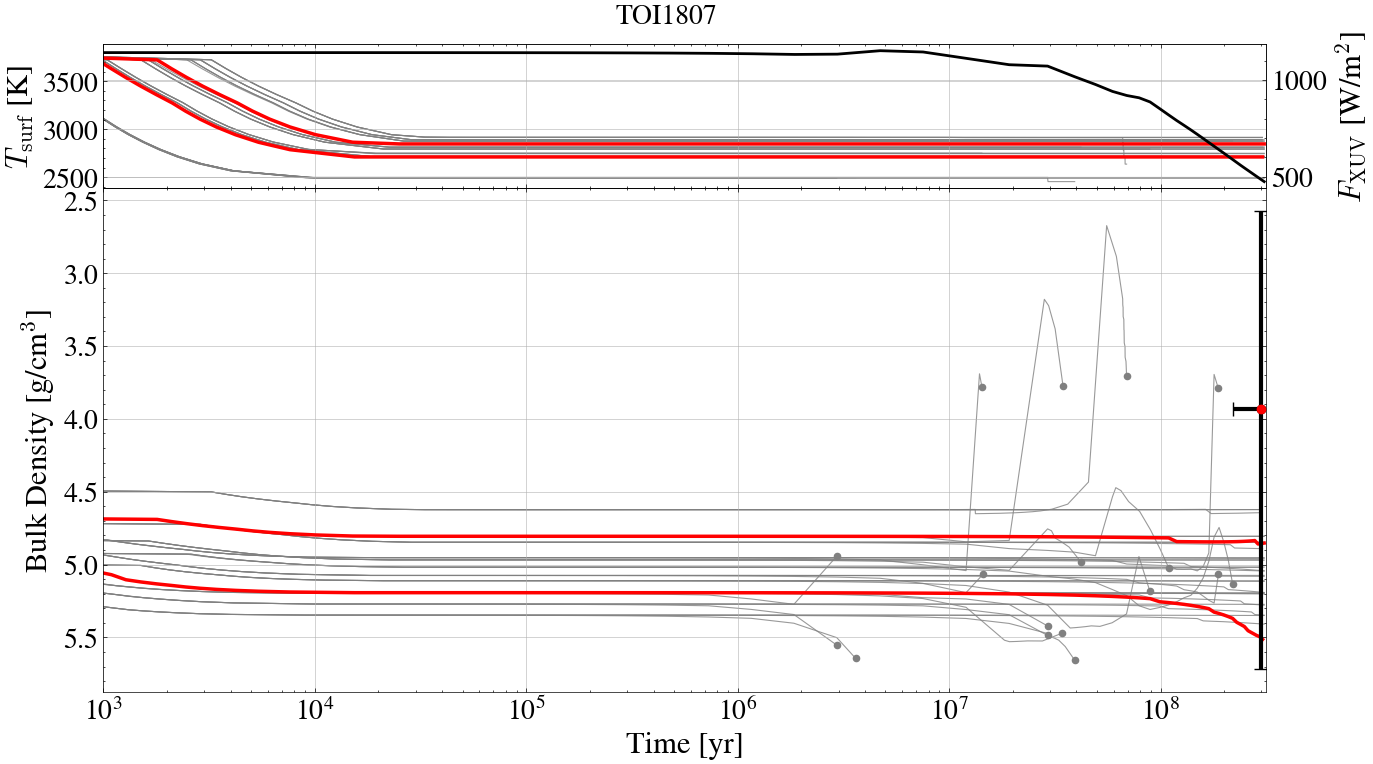

In [61]:
# Okabe-Ito colorblind-friendly palette for H_oceans
colors = {
    1.0:  '#0072B2',  # blue
    5.0:  '#009E73',  # green
    10.0: '#E69F00',  # orange
    20.0: '#D55E00',  # vermillion
    30.0: '#CC79A7',  # pink
}

h_ocean_values = [1.0, 5.0, 10.0, 20.0]
cmap = ListedColormap([colors[h] for h in h_ocean_values])
bounds = [0, 2, 8, 12, 28]
norm = BoundaryNorm(bounds, cmap.N)

# Cases to highlight per planet — all others will be gray
# Use planet names as keys, value is a list of case strings
highlighted_cases = {
    "HD3167":  ["case_000034", "case_000046"],
    "TOI500":  ["case_000042", "case_000046"],
    "TOI561":  ["case_000046"],
    "TOI1416": ["case_000034", "case_000038"],
    "TOI1807": ["case_000022", "case_000026"],
}

for planet, simulations in data_all.items():
    fig = figure(figsize=(15, 8))
    fig.suptitle(rf"{planet}",fontsize=20, y=0.98)

    frame   = fig.add_axes([0.125, 0.12, 0.775, 0.63])
    ax_temp = fig.add_axes([0.125, 0.75, 0.775, 0.18], sharex=frame)


    ax_temp.set_ylabel(r'$T_\mathrm{surf}$ [K]')
    ax_temp.set_xscale('log')
    ax_temp.tick_params(labelbottom=False)

    age      = star_age[planet_names.index(f"{planet}")]
    age_min  = star_age_min[planet_names.index(f"{planet}")]
    age_max  = star_age_max[planet_names.index(f"{planet}")]
    bd       = bulk_density_avg[planet_names.index(f"{planet}")]
    bd_min   = bulk_density_min[planet_names.index(f"{planet}")]
    bd_max   = bulk_density_max[planet_names.index(f"{planet}")]

    longest_sim = None
    max_time = -np.inf
    highlight = highlighted_cases.get(planet, [])

    for sim in simulations:
        is_highlighted = sim["case"] in highlight
        color   = 'red' if is_highlighted else 'gray'
        lw      = 2.5 if is_highlighted else 0.8
        zorder  = 2 if is_highlighted else 1

        frame.plot(sim["x"], sim["y"]/1000,
                   color=color, linestyle='solid', alpha=1.0 if is_highlighted else 0.8, linewidth=lw, zorder=zorder)
        if sim["x"][-1] < age:
            frame.scatter(sim["x"][-1], sim["y"][-1]/1000, color=color, s=20, zorder=zorder+1)
        ax_temp.plot(sim["x"], sim["t_surf"],
                     color=color, linestyle='solid', alpha=1.0 if is_highlighted else 0.8, linewidth=lw, zorder=zorder)

        if sim["x"][-1] > max_time:
            max_time = sim["x"][-1]
            longest_sim = sim

    if longest_sim is not None:
        ax2 = ax_temp.twinx()
        ax2.plot(longest_sim["x"], longest_sim["F_xuv"], color='black', alpha=1.0, linewidth=2.0)
        ax2.set_ylabel(r'$F_\mathrm{XUV}$ [W/m$^2$]')
        ax2.tick_params(axis='both', which='major')

    frame.errorbar(age, bd,
                   xerr=([abs(age_min-age)], [abs(age_max-age)]),
                   yerr=([abs(bd_min-bd)],   [abs(bd_max-bd)]),
                   fmt='o', color='black', ecolor='black', elinewidth=3, capsize=5, zorder=5)
    frame.scatter(age, bd, color='red', zorder=6)

    frame.set_xlabel('Time [yr]')
    frame.set_ylabel(r'Bulk Density [g/cm$^3$]')
    frame.set_xscale('log')
    frame.tick_params(axis='both', which='major')
    frame.invert_yaxis()
    frame.set_xlim(1e3, age*1.05)
    if planet != "TOI431" and planet != "lhs1478" and planet != "K2141":
        savefig(f"thesis-plots/{planet}_bulk_density.pdf", format='pdf')
        show()
    plt.close()


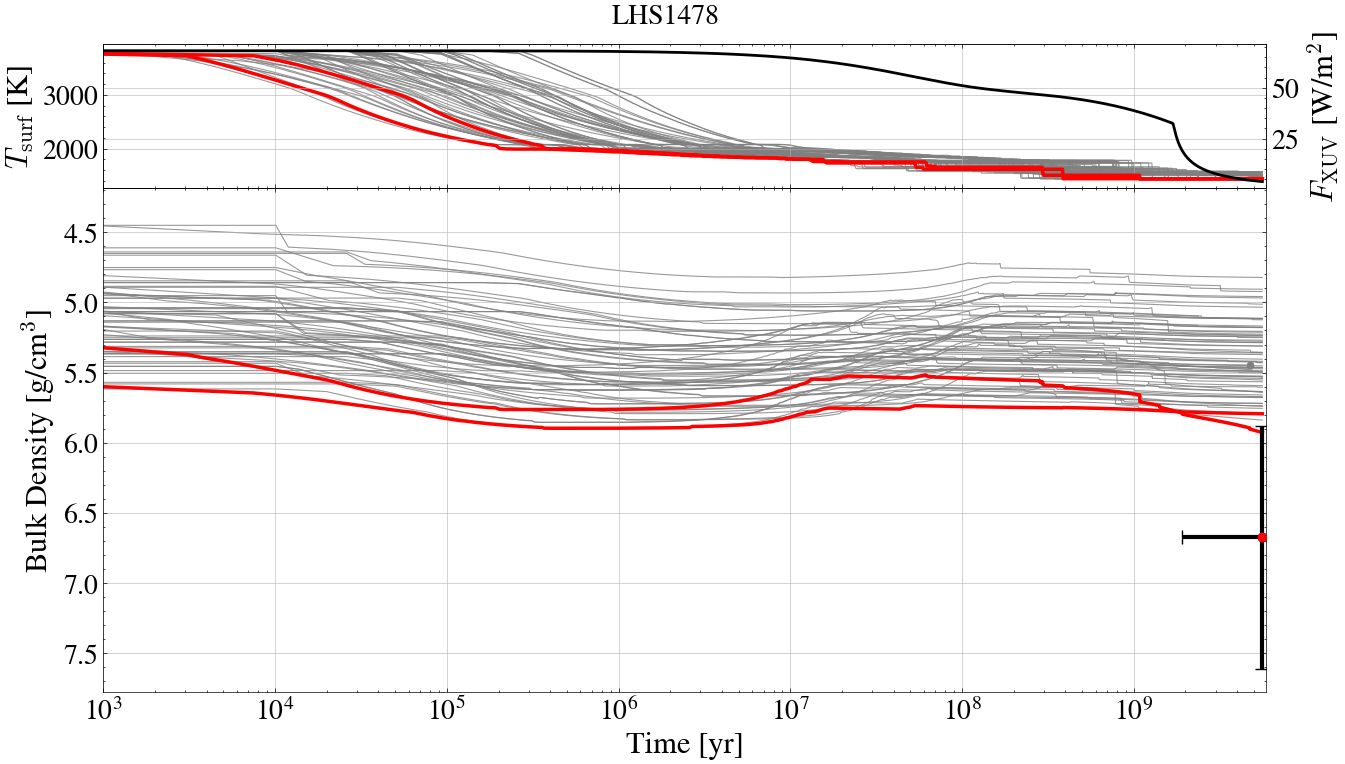

In [48]:
# plot for LHS1478 using bulk_density_evolution_LHS.pkl
with open('bulk_density_evolution_LHS.pkl', 'rb') as f:
    data_lhs = pickle.load(f)

highlighted_cases_lhs = ["case_000001", "case_000011"]

planet = "lhs1478"
simulations = data_lhs[planet]

fig = figure(figsize=(15, 8))
fig.suptitle(rf"LHS1478", fontsize=20, y=0.98)

frame   = fig.add_axes([0.125, 0.12, 0.775, 0.63])
ax_temp = fig.add_axes([0.125, 0.75, 0.775, 0.18], sharex=frame)


ax_temp.set_ylabel(r'$T_\mathrm{surf}$ [K]')
ax_temp.set_xscale('log')
ax_temp.tick_params(labelbottom=False)

age      = star_age[planet_names.index(planet)]
age_min  = star_age_min[planet_names.index(planet)]
age_max  = star_age_max[planet_names.index(planet)]
bd       = bulk_density_avg[planet_names.index(planet)]
bd_min   = bulk_density_min[planet_names.index(planet)]
bd_max   = bulk_density_max[planet_names.index(planet)]

longest_sim = None
max_time = -np.inf

for sim in simulations:
    is_highlighted = sim["case"] in highlighted_cases_lhs
    color   = 'red' if is_highlighted else 'gray'
    lw      = 2.5 if is_highlighted else 0.8
    zorder  = 2 if is_highlighted else 1
    alpha   = 1.0 if is_highlighted else 0.8

    frame.plot(sim["x"], sim["y"]/1000,
               color=color, linestyle='solid', alpha=alpha, linewidth=lw, zorder=zorder)
    if sim["x"][-1] < age:
        frame.scatter(sim["x"][-1], sim["y"][-1]/1000, color=color, s=20, zorder=zorder+1)
    ax_temp.plot(sim["x"], sim["t_surf"],
                 color=color, linestyle='solid', alpha=alpha, linewidth=lw, zorder=zorder)

    if sim["x"][-1] > max_time:
        max_time = sim["x"][-1]
        longest_sim = sim

if longest_sim is not None:
    ax2 = ax_temp.twinx()
    ax2.plot(longest_sim["x"], longest_sim["F_xuv"], color='black', alpha=1.0, linewidth=2.0)
    ax2.set_ylabel(r'$F_\mathrm{XUV}$ [W/m$^2$]')
    ax2.tick_params(axis='both', which='major')

frame.errorbar(age, bd,
               xerr=([abs(age_min-age)], [abs(age_max-age)]),
               yerr=([abs(bd_min-bd)],   [abs(bd_max-bd)]),
               fmt='o', color='black', ecolor='black', elinewidth=3, capsize=5, zorder=5)
frame.scatter(age, bd, color='red', zorder=6)

frame.set_xlabel('Time [yr]')
frame.set_ylabel(r'Bulk Density [g/cm$^3$]')
frame.set_xscale('log')
frame.tick_params(axis='both', which='major')
frame.invert_yaxis()
frame.set_xlim(1e3, age*1.05)

savefig(f"thesis-plots/{planet}_bulk_density.pdf", format='pdf')
show()
plt.close()


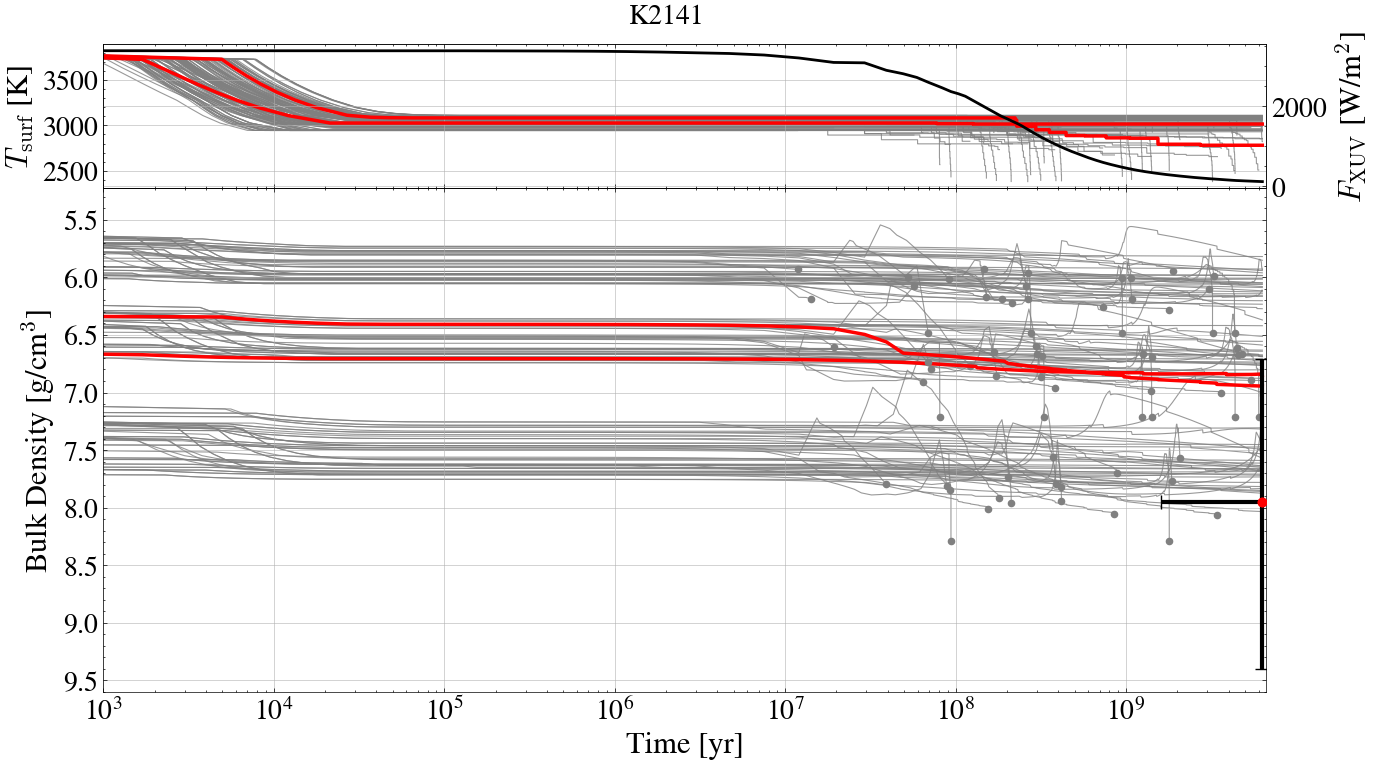

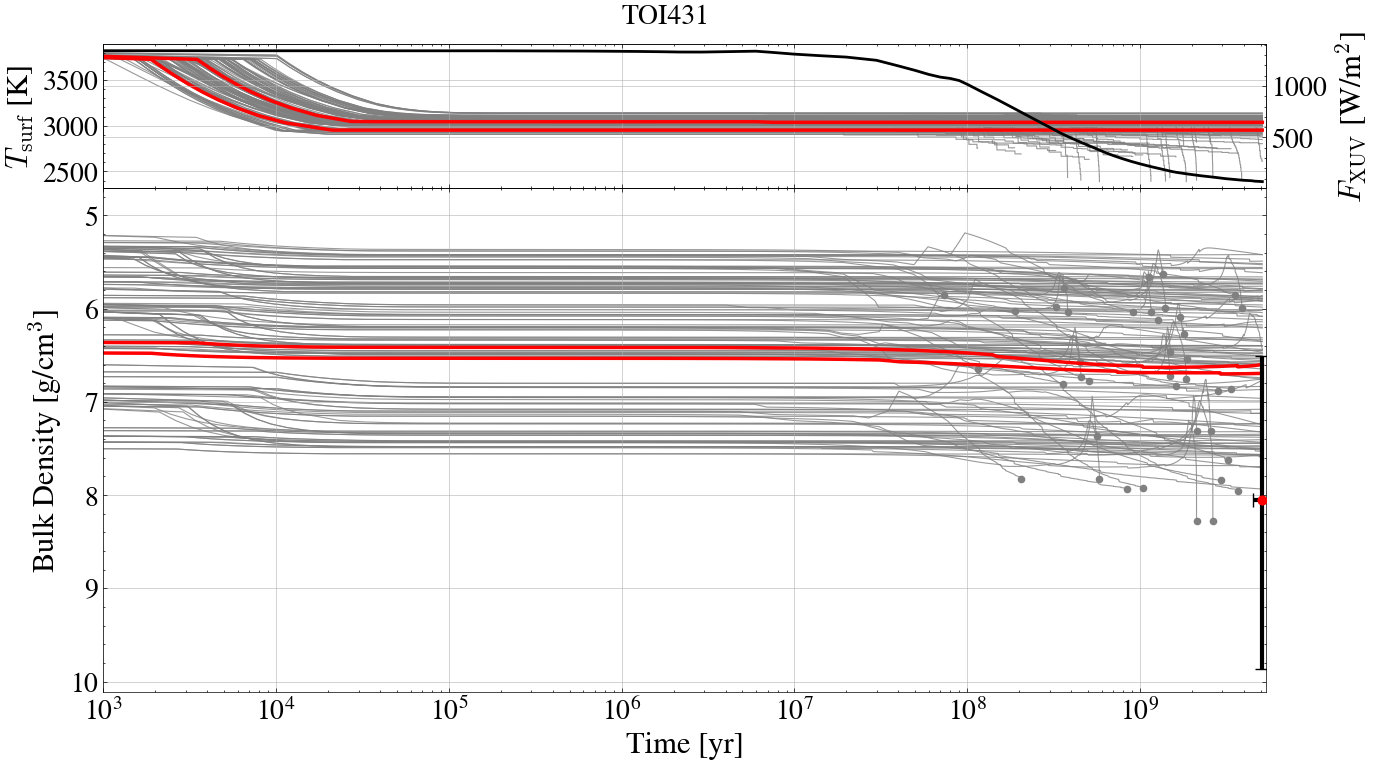

In [49]:
# plot for TOI431 and K2141 using bulk_density_evolution_K2TOI431.pkl
with open('bulk_density_evolution_K2TOI431.pkl', 'rb') as f:
    data_k2toi = pickle.load(f)

highlighted_cases_k2toi = {
    "TOI431": ["case_000034", "case_000082"],
    "K2141":  ["case_000088", "case_000124"],
}

for planet, simulations in data_k2toi.items():
    if planet not in highlighted_cases_k2toi:
        continue
    fig = figure(figsize=(15, 8))
    fig.suptitle(rf"{planet}", fontsize=20, y=0.98)

    frame   = fig.add_axes([0.125, 0.12, 0.775, 0.63])
    ax_temp = fig.add_axes([0.125, 0.75, 0.775, 0.18], sharex=frame)

    ax_temp.set_ylabel(r'$T_\mathrm{surf}$ [K]')
    ax_temp.set_xscale('log')
    ax_temp.tick_params(labelbottom=False)

    age      = star_age[planet_names.index(planet)]
    age_min  = star_age_min[planet_names.index(planet)]
    age_max  = star_age_max[planet_names.index(planet)]
    bd       = bulk_density_avg[planet_names.index(planet)]
    bd_min   = bulk_density_min[planet_names.index(planet)]
    bd_max   = bulk_density_max[planet_names.index(planet)]

    highlight = highlighted_cases_k2toi.get(planet, [])
    longest_sim = None
    max_time = -np.inf

    for sim in simulations:
        is_highlighted = sim["case"] in highlight
        color   = 'red' if is_highlighted else 'gray'
        lw      = 2.5 if is_highlighted else 0.8
        zorder  = 2 if is_highlighted else 1
        alpha   = 1.0 if is_highlighted else 0.8

        frame.plot(sim["x"], sim["y"]/1000,
                   color=color, linestyle='solid', alpha=alpha, linewidth=lw, zorder=zorder)
        if sim["x"][-1] < age:
            frame.scatter(sim["x"][-1], sim["y"][-1]/1000, color=color, s=20, zorder=zorder+1)
        ax_temp.plot(sim["x"], sim["t_surf"],
                     color=color, linestyle='solid', alpha=alpha, linewidth=lw, zorder=zorder)

        if sim["x"][-1] > max_time:
            max_time = sim["x"][-1]
            longest_sim = sim

    if longest_sim is not None:
        ax2 = ax_temp.twinx()
        ax2.plot(longest_sim["x"], longest_sim["F_xuv"], color='black', alpha=1.0, linewidth=2.0)
        ax2.set_ylabel(r'$F_\mathrm{XUV}$ [W/m$^2$]')
        ax2.tick_params(axis='both', which='major')

    frame.errorbar(age, bd,
                   xerr=([abs(age_min-age)], [abs(age_max-age)]),
                   yerr=([abs(bd_min-bd)],   [abs(bd_max-bd)]),
                   fmt='o', color='red', ecolor='black', elinewidth=3, capsize=5, zorder=5)
    frame.scatter(age, bd, color='red', zorder=6)

    frame.set_xlabel('Time [yr]')
    frame.set_ylabel(r'Bulk Density [g/cm$^3$]')
    frame.set_xscale('log')
    frame.tick_params(axis='both', which='major')
    frame.invert_yaxis()
    frame.set_xlim(1e3, age*1.05)
    
    savefig(f"thesis-plots/{planet}_bulk_density.pdf", format='pdf')
    show()
    plt.close()


# Atmosphere composition plots

In [70]:
with open('bulk_density_evolution.pkl', 'rb') as f:
    data_all = pickle.load(f)

with open('bulk_density_evolution_LHS.pkl', 'rb') as f:
    data_lhs = pickle.load(f)

with open('bulk_density_evolution_K2TOI431.pkl', 'rb') as f:
    data_k2toi = pickle.load(f)

# for each pickle go through each planet and extract the final vmrs of the highlighted cases
final_vmr_data = {}
for name in planet_names:
    final_vmr_data[name] = {}
    if name == "lhs1478":
        simulations = data_lhs[name]
        highlight = highlighted_cases_lhs
        for sim in simulations:
            if sim["case"] in highlight:
                final_vmr_data[name][sim["case"]] = {
                    "H2O": float(sim['h2o_vmr_final']),
                    "CO2": float(sim['co2_vmr_final']),
                    "O2": float(sim['o2_vmr_final']),
                    "N2": float(sim['n2_vmr_final']),
                    "H2": float(sim['h2_vmr_final']),
                    "SO2": float(sim['so2_vmr_final']),
                    "CH4": float(sim['ch4_vmr_final']),
                    "CO": float(sim['co_vmr_final']),
                    "NH3": float(sim['nh3_vmr_final']),
                    "S2": float(sim['s2_vmr_final']),
                    "H2S": float(sim['h2s_vmr_final']),
                    "surface_pressure": float(sim['p_surf'])
                }
    elif name == 'TOI431' or name == 'K2141':
        simulations = data_k2toi[name]
        highlight = highlighted_cases_k2toi.get(name, [])
        for sim in simulations:
            if sim["case"] in highlight:
                final_vmr_data[name][sim["case"]] = {
                    "H2O": float(sim['h2o_vmr_final']),
                    "CO2": float(sim['co2_vmr_final']),
                    "O2": float(sim['o2_vmr_final']),
                    "N2": float(sim['n2_vmr_final']),
                    "H2": float(sim['h2_vmr_final']),
                    "SO2": float(sim['so2_vmr_final']),
                    "CH4": float(sim['ch4_vmr_final']),
                    "CO": float(sim['co_vmr_final']),
                    "NH3": float(sim['nh3_vmr_final']),
                    "S2": float(sim['s2_vmr_final']),
                    "H2S": float(sim['h2s_vmr_final']),
                    "surface_pressure": float(sim['p_surf'])
                }
    else:
        simulations = data_all[name]
        highlight = highlighted_cases.get(name, [])
        for sim in simulations:
            if sim["case"] in highlight:
                final_vmr_data[name][sim["case"]] = {
                    "H2O": float(sim['h2o_vmr_final']),
                    "CO2": float(sim['co2_vmr_final']),
                    "O2": float(sim['o2_vmr_final']),
                    "N2": float(sim['n2_vmr_final']),
                    "H2": float(sim['h2_vmr_final']),
                    "SO2": float(sim['so2_vmr_final']),
                    "CH4": float(sim['ch4_vmr_final']),
                    "CO": float(sim['co_vmr_final']),
                    "NH3": float(sim['nh3_vmr_final']),
                    "S2": float(sim['s2_vmr_final']),
                    "H2S": float(sim['h2s_vmr_final']),
                    "surface_pressure": float(sim['p_surf'])
                }
#save final_vmr_data to a new pickle
with open('final_vmr_data.pkl', 'wb') as f:
    pickle.dump(final_vmr_data, f)

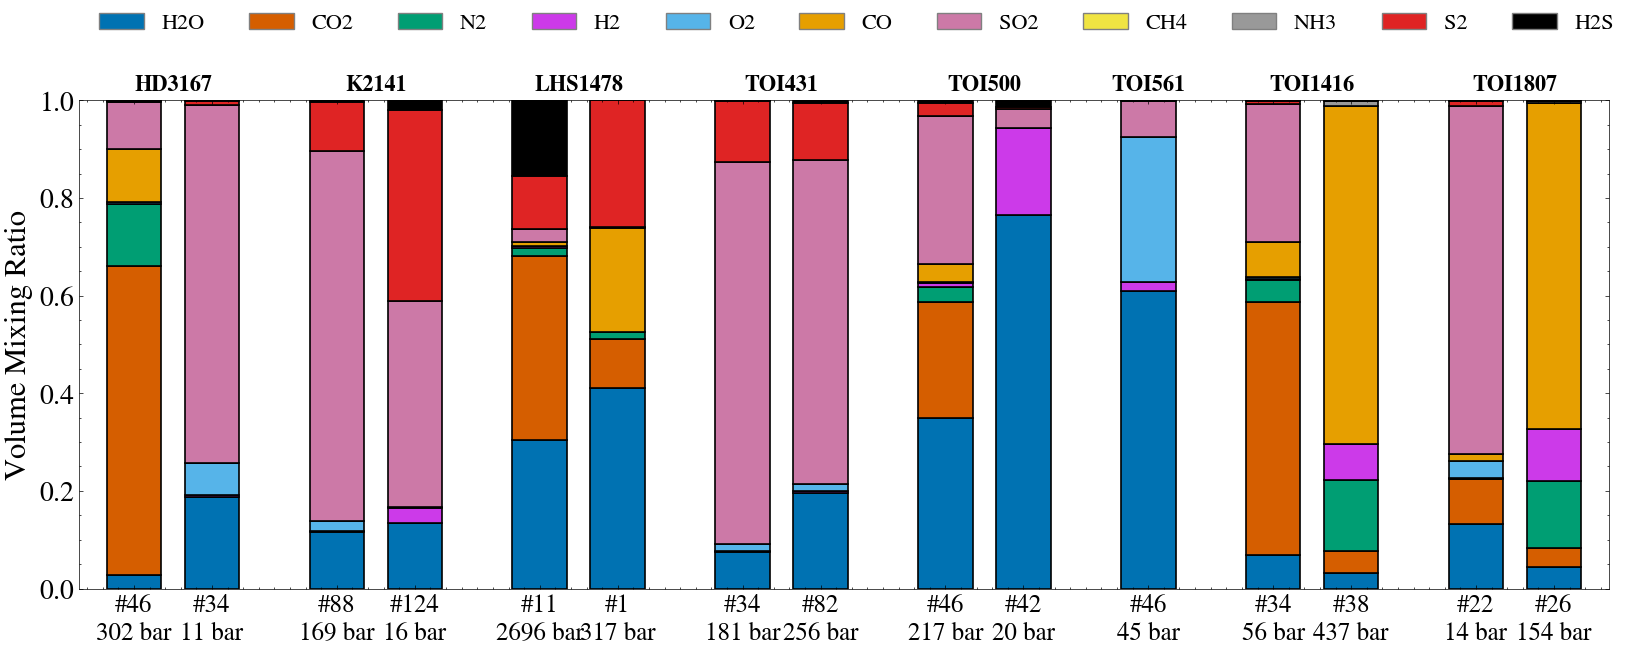

In [78]:
# Atmospheric composition bar chart for all highlighted cases
molecules = ["H2O", "CO2", "N2","H2", "O2", "CO", "SO2", "CH4", "NH3", "S2", "H2S"]

# Okabe-Ito + extras for molecules
mol_colors = {
    "H2O":  "#0072B2",
    "CO2":  "#D55E00",
    "N2":   "#009E73",
    "H2":   "#CC3AE9",
    "O2":   "#56B4E9",
    "CO":   "#E69F00",
    "SO2":  "#CC79A7",
    "CH4":  "#F0E442",
    "NH3":  "#999999",
    "S2":   "#DF2424",
    "H2S":  "#000000"
}

# collect all bars in order: for each planet, one bar per highlighted case
bar_labels = []   # x-tick labels: "case_XXXXXX\nP=XXX bar"
bar_planet = []   # which planet each bar belongs to (for grouping spacing)
bar_vmrs   = []   # list of dicts {molecule: vmr}

for planet in planet_names:
    cases = final_vmr_data.get(planet, {})
    for case, vals in cases.items():
        case_num = int(case.split("_")[-1])
        bar_labels.append(f"#{case_num}\n{vals['surface_pressure']:.0f} bar")
        bar_planet.append(planet)
        bar_vmrs.append(vals)

# build x positions with a gap between planets
x_positions = []
planet_centers = {}
x = 0
prev_planet = None
for i, planet in enumerate(bar_planet):
    if prev_planet is not None and planet != prev_planet:
        x += 0.6  # extra gap between planet groups
    x_positions.append(x)
    x += 1.0
    prev_planet = planet

# compute planet label center positions
for planet in planet_names:
    idxs = [i for i, p in enumerate(bar_planet) if p == planet]
    if idxs:
        planet_centers[planet] = (x_positions[idxs[0]] + x_positions[idxs[-1]]) / 2

fig, ax = plt.subplots(figsize=(max(14, len(bar_labels)*1.2), 7))
ax.grid(False)

for i, (xpos, vmrs) in enumerate(zip(x_positions, bar_vmrs)):
    bottom = 0.0
    for mol in molecules:
        val = vmrs.get(mol, 0.0)
        if val > 0:
            ax.bar(xpos, val, bottom=bottom, width=0.7,
                   color=mol_colors[mol], edgecolor='black', linewidth=1.2)
            bottom += val

# x-axis: case name + pressure below, planet name above as group label
ax.set_xticks(x_positions)
ax.set_xticklabels(bar_labels, ha='center', fontsize=rcParams['xtick.labelsize']-2)

# planet name annotations above the bars
ymax = ax.get_ylim()[1]
for planet, cx in planet_centers.items():
    ax.annotate(planet.upper() if planet == 'lhs1478' else planet, xy=(cx, 1.02), xycoords=('data', 'axes fraction'),
                ha='center', fontweight='bold')

# legend
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=mol_colors[m], edgecolor='gray', label=m) for m in molecules]
ax.legend(handles=legend_handles, loc='upper left', ncol=len(molecules),
           bbox_to_anchor=(0.0, 1.22), frameon=False)

ax.set_ylabel('Volume Mixing Ratio')
ax.set_ylim(0, 1)
ax.set_xlim(x_positions[0] - 0.7, x_positions[-1] + 0.7)

plt.tight_layout()
savefig('thesis-plots/atmosphere_composition.pdf', format='pdf')
show()
plt.close()
